# Práctica: audio-extract en Python

**Materia:** Recuperación de la Información

`audio-extract` es una librería de Python que simplifica la **extracción de la pista de audio de un archivo de video**, usando `ffmpeg` internamente.

## ¿Para qué sirve?

Sirve para separar el audio de un video (por ejemplo, un `.mp4`) y guardarlo como un archivo de audio independiente (`.mp3`, `.wav`, etc.), sin tener que escribir manualmente los comandos de `ffmpeg`. Es un paso muy común antes de aplicar técnicas de recuperación de información sobre audio: primero se extrae el audio de un video, y luego se puede transcribir (con Whisper), analizar (con librosa) o indexar.

## ¿Cómo funciona?

`audio-extract` es una envoltura (*wrapper*) en Python sobre `ffmpeg`, el motor de línea de comandos para procesar audio y video:

1. Recibe la ruta de un archivo de **video** de entrada.
2. Internamente arma y ejecuta un comando de `ffmpeg` que copia/convierte únicamente el flujo (*stream*) de audio del video, descartando el video.
3. Guarda el resultado en el **formato de salida** indicado (mp3, wav, etc.), opcionalmente recortando por tiempo de inicio y duración.

**Importante:** como `audio-extract` solo arma el comando y se lo pasa a `ffmpeg`, **necesita que `ffmpeg` esté instalado y disponible en el PATH** del sistema. `pip install audio-extract` NO instala `ffmpeg` (es un programa aparte, no una librería de Python).

## ¿Qué tipo de operaciones se pueden realizar?

- Extraer el audio completo de un video: `extract_audio(input_path, output_path)`.
- Elegir el **formato de salida** (`output_format='mp3'`, `'wav'`, etc.).
- Extraer solo un **fragmento**, indicando `start_time` (hh:mm:ss) y `duration` (segundos).
- **Sobrescribir** un archivo de salida existente con `overwrite=True`.

## Instalar ffmpeg en Windows (necesario antes de correr esta práctica)

Si al ejecutar la siguiente celda ves un error como `FileNotFoundError: [WinError 2] El sistema no puede encontrar el archivo especificado`, significa que `ffmpeg` no está instalado o no está en el PATH. Es la causa más común de que esta práctica "no haga nada". Para instalarlo en Windows 10/11, la forma más simple es con `winget` (ya viene incluido en Windows):

```powershell
winget install --id=Gyan.FFmpeg -e
```

Después **cierra y vuelve a abrir** la terminal/VS Code (para que se actualice el PATH) y verifica con:

```powershell
ffmpeg -version
```

Alternativas si `winget` no está disponible: `choco install ffmpeg` (Chocolatey), o descargar el .zip desde [https://www.gyan.dev/ffmpeg/builds/](https://www.gyan.dev/ffmpeg/builds/) y agregar manualmente la carpeta `bin` al PATH del sistema.

In [1]:
import shutil

ffmpeg_path = shutil.which('ffmpeg')
FFMPEG_DISPONIBLE = ffmpeg_path is not None

if FFMPEG_DISPONIBLE:
    print('ffmpeg encontrado en:', ffmpeg_path)
else:
    print('ffmpeg NO esta instalado o no esta en el PATH.')
    print('Instalalo con:  winget install --id=Gyan.FFmpeg -e')
    print('Luego reinicia la terminal/kernel y vuelve a correr esta celda.')
    print('Las siguientes celdas se OMITIRAN automaticamente hasta que ffmpeg este disponible.')

ffmpeg encontrado en: /usr/bin/ffmpeg


### Generar un video de prueba

Como no tenemos un video de ejemplo a la mano, generamos uno sintético con `ffmpeg` (un patrón de color con un tono de audio de fondo) y luego usamos `audio-extract` para separar su pista de audio.

In [2]:
import subprocess, os

if FFMPEG_DISPONIBLE:
    cmd = [
        'ffmpeg', '-y',
        '-f', 'lavfi', '-i', 'testsrc=size=320x240:rate=15:duration=4',
        '-f', 'lavfi', '-i', 'sine=frequency=440:duration=4',
        '-c:v', 'libx264', '-c:a', 'aac', '-shortest',
        'video_demo.mp4'
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    print('Codigo de salida:', result.returncode)
    if result.returncode != 0:
        print('Detalle del error de ffmpeg:')
        print(result.stderr[-800:])
    print('Video generado:', os.path.exists('video_demo.mp4'), '-', os.path.getsize('video_demo.mp4') if os.path.exists('video_demo.mp4') else 0, 'bytes')
else:
    print('Omitido: se requiere ffmpeg instalado (ver instrucciones arriba).')

Codigo de salida: 0
Video generado: True - 57588 bytes


### Extracción del audio completo

In [3]:
if FFMPEG_DISPONIBLE and os.path.exists('video_demo.mp4'):
    from audio_extract import extract_audio
    extract_audio(input_path='video_demo.mp4', output_path='audio_completo.mp3', output_format='mp3', overwrite=True)
    print('Audio extraido:', os.path.exists('audio_completo.mp3'), '-', os.path.getsize('audio_completo.mp3'), 'bytes')
else:
    print('Omitido (requiere ffmpeg y video_demo.mp4). Codigo equivalente:')
    print("  from audio_extract import extract_audio")
    print("  extract_audio(input_path='video_demo.mp4', output_path='audio_completo.mp3', output_format='mp3')")

Success : audio file has been saved to "/sessions/intelligent-practical-bell/mnt/outputs/nb_build/audio_completo.mp3".
Audio extraido: True - 32721 bytes


### Extracción de solo un fragmento (recorte)

Usamos `start_time` y `duration` para extraer únicamente del segundo 1 al 3.

In [4]:
if FFMPEG_DISPONIBLE and os.path.exists('video_demo.mp4'):
    extract_audio(
        input_path='video_demo.mp4',
        output_path='audio_fragmento.wav',
        output_format='wav',
        start_time='00:00:01',
        duration=2,
        overwrite=True
    )
    print('Fragmento extraido:', os.path.exists('audio_fragmento.wav'), '-', os.path.getsize('audio_fragmento.wav'), 'bytes')
else:
    print('Omitido (requiere ffmpeg y video_demo.mp4). Codigo equivalente:')
    print("  extract_audio(input_path='video_demo.mp4', output_path='audio_fragmento.wav', start_time='00:00:01', duration=2)")

Success : audio file has been saved to "/sessions/intelligent-practical-bell/mnt/outputs/nb_build/audio_fragmento.wav".
Fragmento extraido: True - 176478 bytes


### Verificación con librosa

Cargamos el audio extraído para confirmar que efectivamente contiene la señal (el tono de 440 Hz) y graficamos su forma de onda.

Duracion del audio extraido: 4.02 s, sr=44100 Hz


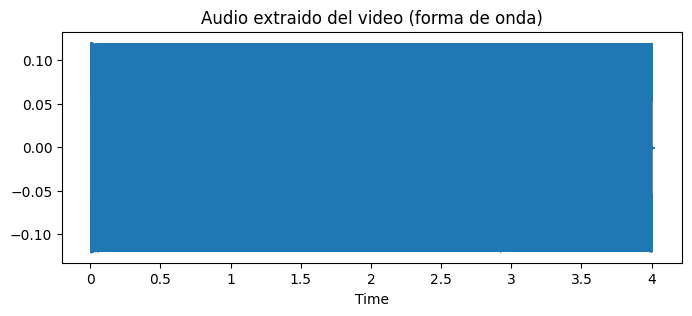

Duracion del fragmento: 2.00 s (esperado ~2s)


In [5]:
if FFMPEG_DISPONIBLE and os.path.exists('audio_completo.mp3'):
    import librosa
    import librosa.display
    import matplotlib.pyplot as plt

    y, sr = librosa.load('audio_completo.mp3', sr=None)
    print(f'Duracion del audio extraido: {librosa.get_duration(y=y, sr=sr):.2f} s, sr={sr} Hz')

    plt.figure(figsize=(8,3))
    librosa.display.waveshow(y, sr=sr)
    plt.title('Audio extraido del video (forma de onda)')
    plt.show()

    y2, sr2 = librosa.load('audio_fragmento.wav', sr=None)
    print(f'Duracion del fragmento: {librosa.get_duration(y=y2, sr=sr2):.2f} s (esperado ~2s)')
else:
    print('Omitido: requiere haber generado audio_completo.mp3 en la celda anterior (necesita ffmpeg).')

## Conclusión

`audio-extract` reduce a una sola línea de código un proceso que normalmente requeriría construir comandos de `ffmpeg` a mano, lo cual es útil como primer paso de cualquier flujo de recuperación de información que empiece a partir de archivos de video (por ejemplo, antes de transcribir con Whisper o analizar con librosa). Su único requisito externo es tener `ffmpeg` instalado en el sistema.